# *Students' Dropout* dataset

[*UCI* webpage](https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success)

First, we import the libraries that we will need to load, process and visualize the data.

Details about the different libraries and provided functions can be found in their respective documentation:
- `numpy` for numerical calculations https://numpy.org/doc/stable/
- `pandas` for data manipulation and analysis https://pandas.pydata.org/docs/
- `pyplot` from `matplotlib` for basic plotting functionalities https://matplotlib.org/stable/
- `seaborn` for data visualization https://seaborn.pydata.org/

The first line below is a Python 'magic command' to display the plots in the notebook.
The last line is to somewhat increase the default figure width.

In [1]:
%matplotlib inline
import numpy
import pandas
import matplotlib.pyplot as plt
import seaborn

plt.rcParams["figure.figsize"] = (10, 5)

The [*Students' Dropout*](https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success) dataset belongs to the area of learning analytics. It contains information about the demographics and socioeconomic background, as well as the academic path and performance of students enrolled in different undergraduate degrees at an institution of higher education in Portugal. The task typically considered is to predict students' academic performance, so as to detect students at risk of failure.

For details about the dataset, the *UCI* webpage points to
- Martins, M.V., Tolledo, D., Machado, J., Baptista, L.M.T., Realinho, V. (2021). *Early Prediction of student’s Performance in Higher Education: A Case Study.* In:  Trends and Applications in Information Systems and Technologies (WorldCIST 2021). Advances in Intelligent Systems and Computing, vol 1365. Springer. https://doi.org/10.1007/978-3-030-72657-7_16

We load the data from the file and create a variable containing the name of the prediction target.

In [2]:
dropout_path = "./predict+students+dropout+and+academic+success/data.csv"
dropout_dtf = pandas.read_csv(dropout_path, sep=";")
dropout_targetname = "Target"

We write a function to list the columns that have missing values in a given dataset, or report that there are none, and we apply it to the dataset we just loaded.

In [3]:
def check_missing_values(dtf):
    cols_missing_values = [c for c in dtf if dtf[c].isna().any()]
    if len(cols_missing_values) > 0:
        print("\n\t- ".join(
            ["The following %s columns contain missing values:" % len(cols_missing_values)]+
            cols_missing_values))
    else:
        print("No values are missing.")

check_missing_values(dropout_dtf)

No values are missing.


We show an outline of the dataset.

In [4]:
dropout_dtf

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4419,1,1,6,9773,1,1,125.0,1,1,1,...,0,6,8,5,12.666667,0,15.5,2.8,-4.06,Graduate
4420,1,1,2,9773,1,1,120.0,105,1,1,...,0,6,6,2,11.000000,0,11.1,0.6,2.02,Dropout
4421,1,1,1,9500,1,1,154.0,1,37,37,...,0,8,9,1,13.500000,0,13.9,-0.3,0.79,Dropout
4422,1,1,1,9147,1,1,180.0,1,37,37,...,0,5,6,5,12.000000,0,9.4,-0.8,-3.12,Graduate


The dataset contains 4424 rows representing enrolled students.
The last attribute, **Target**, represents students performance as a categorical attribute with three different values, namely **Enrolled**, **Dropout** and **Graduate**.

The other thirty-six attributes take numerical values.

Twelve of them represent actual quantities or orderings:
- **Age at enrollment**
- **Application order**, between 0 (first choice) and 9 (last choice)
- **Previous qualification (grade)**, between 0 and 200
- **Admission grade**, between 0 and 200
- **Curricular units 1st sem (credited)** and **Curricular units 2nd sem (credited)**, the number of curricular units credited in the 1st and 2nd semesters, respectively
- **Curricular units 1st sem (enrolled)** and **Curricular units 2nd sem (enrolled)**, the number of curricular units enrolled in the 1st and 2nd semesters, respectively
- **Curricular units 1st sem (evaluations)** and **Curricular units 2nd sem (evaluations)**, the number of evaluations to curricular units in the 1st and 2nd semesters, respectively
- **Curricular units 1st sem (approved)** and **Curricular units 2nd sem (approved)**, the number of curricular units approved in the 1st and 2nd semesters, respectively

Some represent answers to yes/no questions, where values 1 and 0 represent respectively 'yes' and 'no', namely:
- **Displaced**
- **Educational special needs**
- **Debtor**
- **Tuition fees up to date**
- **Scholarship holder**
- **International**

**Gender** and **Daytime/evening attendance** are additional binary attributes, with values 0 and 1 representing respectively **female** and **male**, on one hand, **evening** and **daytime**, on the other hand.

The meaning of the numerical values for the other attributes can be found on the [variables table on the *UCI* webpage](https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success).

We drop the stray tab character from the end of an attribute name.

In [5]:
dropout_dtf.rename(columns={"Daytime/evening attendance\t": "Daytime/evening attendance"}, inplace=True)

We draw a histogram of the students performance per course.

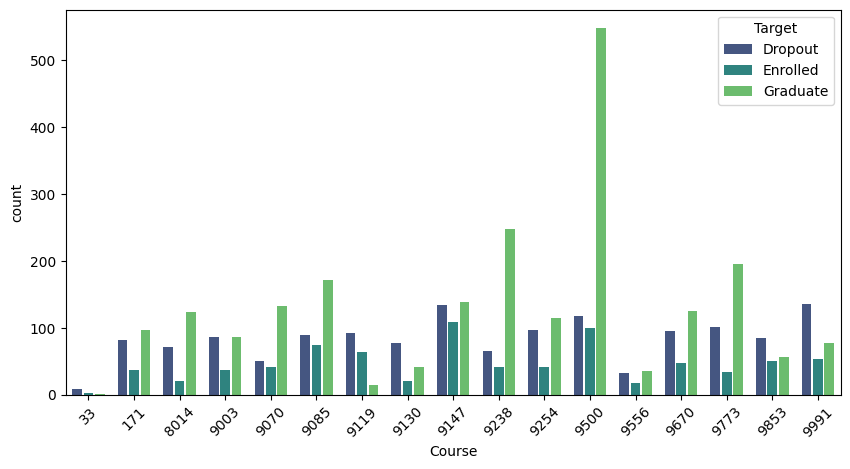

In [6]:
dropout_palette = seaborn.color_palette("viridis", 3)
ax= seaborn.countplot(x=dropout_dtf["Course"], hue=dropout_dtf[dropout_targetname],
                    palette=dropout_palette, width=0.75, dodge=True, gap=0.15)
ax.tick_params("x", rotation=45)

The course names are as follows:
- **33**: Biofuel Production Technologies
- **171**: Animation and Multimedia Design
- **8014**: Social Service (evening attendance)
- **9003**: Agronomy
- **9070**: Communication Design
- **9085**: Veterinary Nursing
- **9119**: Informatics Engineering
- **9130**: Equinculture
- **9147**: Management
- **9238**: Social Service
- **9254**: Tourism
- **9500**: Nursing
- **9556**: Oral Hygiene
- **9670**: Advertising and Marketing Management
- **9773**: Journalism and Communication
- **9853**: Basic Education
- **9991**: Management (evening attendance)

*Nursing (9500)* and *Social service (9238)* are the two courses with the largest number of graduates, both have a small proportion of dropouts compared to graduates. On the other hand, *Informatics Engineering (9119)* has very few graduates and about as many dropouts as graduates and enrolled combined.

Since several attributes have a large number of distinct values, few of which appear frequently in the data, we write a function to select a subset of representative values for a given attribute.

In [7]:
def representative_values(s, rfrac):
    """Select the most frequent values that together represent a fraction `rfrac` (float) of the occurrences in `s` (pandas.Series).
    Returns
        - A copy of the input series where occurrences of representative values are replaced by their position in the selection,
            and occurrences of other values are replaced by `nan`
        - The ordered list of representative values. The last entry is `nan` if some values were not selected as representative
        - The occurrence counts of the values
        - The total number of representative values
    """
    cv = s.value_counts().sort_values(ascending=False)
    tot = len(s)
    nb = (cv.cumsum()/tot < rfrac).sum()+1
    keep_cv = cv.iloc[:nb + 1 if nb + 1 == len(cv) else nb].sort_index()
    values, counts = map(list, zip(*keep_cv.items()))
    s_rep = s.copy()
    if len(keep_cv) < len(cv):
        mask_nan = ~s_rep.isin(values)
        counts.append(mask_nan.sum())
        s_rep.loc[mask_nan] = numpy.nan
        values.append(numpy.nan)
    map_vs = dict([(v, i) for (i, v) in enumerate(values)])
    return s_rep.map(map_vs), values, counts, nb

We use this function to draw histograms showing the distribution of the representative values across the three performance categories for attributes with several representative values.

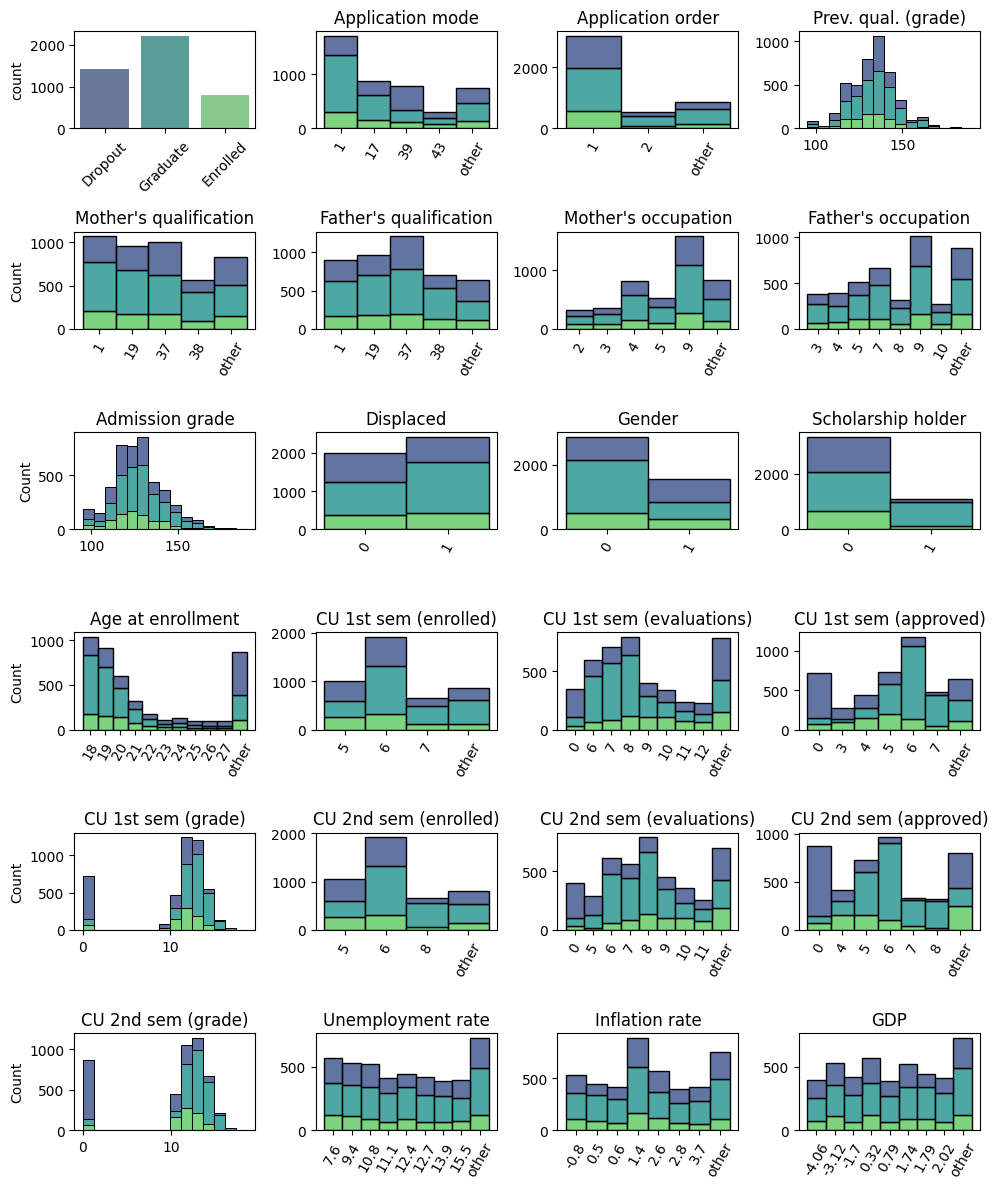

In [8]:
per_row = 4
f, axes = plt.subplots(6, per_row)
ci = 0
seaborn.countplot(x=dropout_dtf[dropout_targetname], hue=dropout_dtf[dropout_targetname],
                    ax=axes[ci//per_row, ci%per_row],
                    palette=dropout_palette, legend=False, alpha=0.8, linewidth=1)
axes[ci//per_row, ci%per_row].set_xlabel("")
axes[ci//per_row, ci%per_row].tick_params("x", rotation=45)
for cid, cname in enumerate(dropout_dtf.columns):
    v_rep, vs, cs, nb = representative_values(dropout_dtf[cname], 0.8)
    if nb <= 1 or cname in [dropout_targetname, "Course"]:
        continue

    ci += 1
    if nb <= 15: # attributes with a few representative values
        seaborn.histplot(x=v_rep, hue=dropout_dtf[dropout_targetname],
                    ax=axes[ci//per_row, ci%per_row], multiple="stack",
                    palette=dropout_palette, discrete=True, legend=False, alpha=0.8)
        if numpy.isnan(vs[-1]):
            vs[-1] = "other"
        axes[ci//per_row, ci%per_row].set_xticks(range(len(vs)), vs,rotation=60)
    else: # attributes with a large number of representative values, actual numerical attributes
        seaborn.histplot(x=dropout_dtf[cname], hue=dropout_dtf[dropout_targetname], bins=15,
                    ax=axes[ci//per_row, ci%per_row], multiple="stack",
                    palette=dropout_palette, legend=False, alpha=0.8)
    if ci%per_row > 0:
        axes[ci//per_row, ci%per_row].set_ylabel("")
    axes[ci//per_row, ci%per_row].set_xlabel("")
    axes[ci//per_row, ci%per_row].set_title(cname\
                                             .replace("Curricular units", "CU")\
                                             .replace("Previous qualification", "Prev. qual."))
f.set_figheight(12)
f.tight_layout()

We provide clarifications for the values of attributes appearing in the histograms.

- **Application mode**:
	- **1**: 1st phase - general contingent
	- **17**: 2nd phase - general contingent
	- **39**: Over 23 years old
	- **43**: Change of course
- **Mother's qualification** and **Father's qualification**: Education Level
	- **1**: Secondary Education - 12th Year of Schooling or Equiv.
	- **19**: Basic Education 3rd Cycle (9th/10th/11th Year) or Equiv.
	- **37**: Basic education 1st cycle (4th/5th year) or Equiv.
	- **38**: Basic Education 2nd Cycle (6th/7th/8th Year) or Equiv.
- **Mother's occupation** and **Father's occupation**:
	- **2**: Specialists in Intellectual and Scientific Activities
	- **3**: Intermediate Level Technicians and Professions
	- **4**: Administrative staff
	- **5**: Personal Services, Security and Safety Workers and Sellers
	- **6**: Farmers and Skilled Workers in Agriculture, Fisheries and Forestry
	- **7**: Skilled Workers in Industry, Construction and Craftsmen
	- **8**: Installation and Machine Operators and Assembly Workers
	- **9**: Unskilled Workers
	- **10**: Armed Forces Professions

We note that dropouts are over-represented among students who enrolled at age 23 and over (`Application mode` value 39 and left-most bars in `Age at enrollment`).
On the other hand, the proportion of graduates is much higher among female students (`Gender` value 0) than among male students, and even more so among scholarship holders (`Scholarship` value 1) than among students who do not receive a scholarship. It is also higher among students who enrolled in and got approved more curricular units than average (`CU 1st/2nd sem (enrolled/approved)`), received above average grades (`CU 1st/2nd sem (grade)`), and who took evaluations for between 6 and 8 curricular units (`CU 1st/2nd sem (evaluations)`)